# Math for ML — Part 4. Basics of statistics

#### [Math for ML. Part 1. Basics of Linear algebra & analytic geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part-1-lin-algebra-an-geometry)

#### [Math for ML - Part 2. Basics of calculus (Mathematical Analysis)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)

#### [Math for ML - Part 3. Basics of probability theory](https://www.kaggle.com/code/kupershtein/math-for-ml-part-3-basics-of-probability-theory)


## Why mathematical statistics matters in ML

Probability theory studies uncertainty in abstract random processes.  
Mathematical statistics studies how we use **data samples** to make conclusions about a larger population.

This is exactly what machine learning does all the time:

- we do not observe the full population of all possible future data;
- we work with a finite dataset;
- we estimate patterns from that dataset;
- we evaluate uncertainty and generalization.

Statistical thinking is essential for:

- understanding samples and bias;
- describing data correctly;
- estimating unknown quantities;
- checking relationships between variables;
- comparing models and groups;
- testing hypotheses;
- making robust decisions under uncertainty.

<a id=topics-covered></a>
    
## Topics covered

1. [Population, sample, and sampling](#1-population-sample-and-sampling)  
2. [How to form samples in practice](#2-how-to-form-samples-in-practice)  
3. [Dataset structure and variable types](#3-dataset-structure-and-variable-types)  
4. [Descriptive statistics: central tendency](#4-descriptive-statistics-central-tendency)  
5. [Descriptive statistics: variability and quantiles](#5-descriptive-statistics-variability-and-quantiles)  
6. [Distribution shape: skewness and kurtosis](#6-distribution-shape-skewness-and-kurtosis)  
7. [Data visualization for statistics](#7-data-visualization-for-statistics)  
8. [Estimators, bias, and standard error](#8-estimators-bias-and-standard-error)  
9. [Confidence intervals](#9-confidence-intervals)  
10. [Bootstrapping](#10-bootstrapping)  
11. [Covariance and correlation](#11-covariance-and-correlation)  
12. [Multicollinearity and VIF](#12-multicollinearity-and-vif)  
13. [Hypotheses, significance, and p-value](#13-hypotheses-significance-and-p-value)  
14. [Type I and Type II errors](#14-type-i-and-type-ii-errors)  
15. [Common statistical tests](#15-common-statistical-tests)  
16. [ANOVA](#16-anova)  
17. [Regression from a statistical viewpoint](#17-regression-from-a-statistical-viewpoint)  
18. [Practical EDA workflow for ML](#18-practical-eda-workflow-for-ml)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

<a id=1-population-sample-and-sampling></a>
# 1. Population, Sample, and Sampling

### Population and sample

A **population** is the full set of objects or events we care about.

A **sample** is a subset drawn from that population.

Examples:

- population: all customers of a platform;
- sample: 10,000 users observed this month.

### Sample size and representativeness

The **sample size** is the number of observations in the sample.

A sample is **representative** if it reflects the important properties of the population.

### Why this matters in ML

In ML, the dataset is usually a sample from some larger real-world process.

This matters because:

- the model learns from the sample, not from the full population;
- poor samples create biased models;
- train/test mismatch often comes from sampling issues;
- class imbalance can be seen as a sampling issue.

### Sampling methods

Common sampling methods:

- simple random sampling;
- stratified sampling;
- cluster sampling;
- systematic sampling.

### Common mistakes

- Thinking more data automatically means better data.
- Ignoring sampling bias.
- Using non-representative training data and expecting generalization.

### ML takeaway

The quality of a model depends not only on the algorithm, but also on how the sample was collected.

### Quick check

1. What is the difference between population and sample?  
2. Why is representativeness important in ML?  
3. Why can class imbalance be viewed as a sampling problem?

[Back to Topics](#topics-covered)

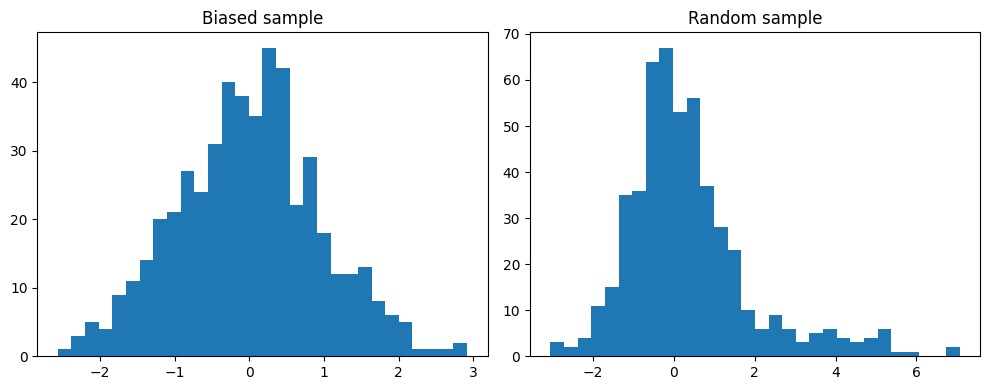

Population mean: 0.38975012458598834
Biased sample mean: -0.013126150466933863
Random sample mean: 0.3629357084324896


In [2]:
population = np.concatenate([
    rng.normal(loc=0, scale=1, size=9000),
    rng.normal(loc=4, scale=1, size=1000)
])

biased_sample = population[:500]
random_sample = rng.choice(population, size=500, replace=False)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(biased_sample, bins=30)
plt.title("Biased sample")

plt.subplot(1, 2, 2)
plt.hist(random_sample, bins=30)
plt.title("Random sample")

plt.tight_layout()
plt.show()

print("Population mean:", population.mean())
print("Biased sample mean:", biased_sample.mean())
print("Random sample mean:", random_sample.mean())

<a id=2-how-to-form-samples-in-practice></a>
# 2. How to form samples in practice

### Why this section matters

It is useful not only to define sampling methods, but also to see how they can be constructed in practice using Python tools.

Below we show several common ways to create samples.

### Simple random sample

Choose observations uniformly at random from the dataset.

### Stratified sample

Split the population into groups called **strata**, then sample from each group.

This is useful when class balance or subgroup representation matters.

### Systematic sample

Pick every $k$-th observation after a chosen starting point.

### Why this matters in ML

In ML practice, these ideas connect directly to:

- train/test splitting;
- class-preserving sampling;
- rebalancing;
- fair evaluation across groups.

### Common mistakes

- Using only random sampling when important minority groups are rare.
- Forgetting that stratification is often crucial in classification.
- Assuming systematic sampling is always safe when data is ordered.

### ML takeaway

Sampling is not only a theory topic; it is a practical tool that shapes model quality and evaluation.

### Quick check

1. Why is stratified sampling useful in classification?  
2. What is a possible risk of systematic sampling?  
3. Why can sample-construction choices affect fairness and evaluation?

[Back to Topics](#topics-covered)

In [3]:
df_sampling = pd.DataFrame({
    "value": rng.normal(size=1000),
    "class_label": np.where(rng.random(1000) < 0.85, "majority", "minority"),
    "group": rng.choice(["A", "B", "C"], size=1000, p=[0.6, 0.3, 0.1])
})

display(df_sampling.head())
print(df_sampling["class_label"].value_counts())
print(df_sampling["group"].value_counts())

,value,class_label,group
0,0.113961,majority,A
1,1.125268,majority,A
2,1.384907,majority,A
3,-0.410847,majority,B
4,0.423506,majority,A


class_label
majority    860
minority    140
Name: count, dtype: int64
group
A    615
B    290
C     95
Name: count, dtype: int64


Original class proportions:
class_label
majority    0.86
minority    0.14
Name: proportion, dtype: float64

Random stratified sample proportions:
class_label
majority    0.9
minority    0.1
Name: proportion, dtype: float64

Balanced stratified sample proportions:
class_label
majority    0.5
minority    0.5
Name: proportion, dtype: float64

Proportional stratified sample proportions:
class_label
majority    0.858333
minority    0.141667
Name: proportion, dtype: float64

Systematic stratified sample proportions:
class_label
majority    0.872
minority    0.128
Name: proportion, dtype: float64


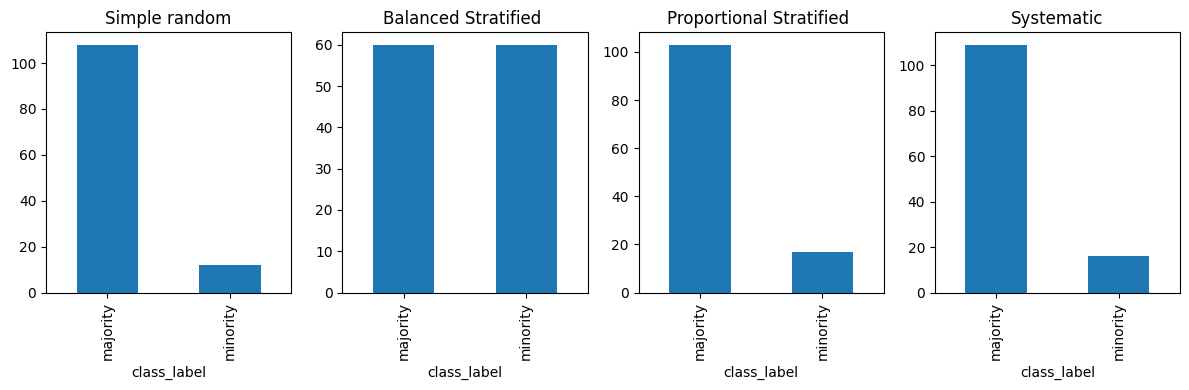

In [4]:
sample_size = 120

simple_random = df_sampling.sample(n=sample_size, random_state=42)

proportional_stratified = (
    df_sampling.groupby("class_label", group_keys=False)
    .apply(lambda x: x.sample(
        n=round(sample_size * len(x) / len(df_sampling)),
        random_state=42
    ))
)

balanced_stratified = (
    df_sampling.groupby("class_label", group_keys=False)
    .apply(lambda x: x.sample(n=60, random_state=42))
)

k = 8
start = 3
systematic = df_sampling.iloc[start::k]

print("Original class proportions:")
print(df_sampling["class_label"].value_counts(normalize=True))

print("\nRandom stratified sample proportions:")
print(simple_random["class_label"].value_counts(normalize=True))

print("\nBalanced stratified sample proportions:")
print(balanced_stratified["class_label"].value_counts(normalize=True))

print("\nProportional stratified sample proportions:")
print(proportional_stratified["class_label"].value_counts(normalize=True))

print("\nSystematic stratified sample proportions:")
print(systematic["class_label"].value_counts(normalize=True))


plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
simple_random["class_label"].value_counts().plot(kind="bar", title="Simple random")

plt.subplot(1, 4, 2)
balanced_stratified["class_label"].value_counts().plot(kind="bar", title="Balanced Stratified ")

plt.subplot(1, 4, 3)
proportional_stratified["class_label"].value_counts().plot(kind="bar", title="Proportional Stratified ")

plt.subplot(1, 4, 4)
systematic["class_label"].value_counts().plot(kind="bar", title="Systematic")

plt.tight_layout()
plt.show()

<a id=3-dataset-structure-and-variable-types></a>
# 3. Dataset structure and variable types

### Dataset structure

In tabular ML, data is often represented as:

- rows = observations or objects;
- columns = features;
- target column = outcome we want to predict.

We usually write:

- $X$ for the feature matrix;
- $y$ for the target vector.

### Types of variables

Common variable types:

- **quantitative**;
- **discrete quantitative**;
- **continuous quantitative**;
- **ordinal**;
- **nominal**;
- **binary**.

### Why this matters in ML

Variable type affects:

- encoding strategy;
- visualization choices;
- summary statistics;
- model assumptions;
- preprocessing.

### Common mistakes

- Treating categorical IDs as numeric variables with meaningful magnitude.
- Using mean for variables where median or mode is more appropriate.
- Forgetting that model input type should match variable meaning.

### ML takeaway

Before modeling, we must understand what each variable actually represents.

### Quick check

1. What is the difference between $X$ and $y$?  
2. Why does variable type matter for preprocessing?  
3. Is a postal code a quantitative variable in the statistical sense?

[Back to Topics](#topics-covered)

In [5]:
df = pd.DataFrame({
    # quantitative
    "income": rng.normal(50000, 12000, size=10).round(0),

    # discrete quantitative
    "num_purchases": rng.integers(0, 20, size=10),

    # continuous quantitative
    "height_m": rng.normal(1.75, 0.12, size=10).round(2),

    # ordinal
    "education_level": rng.choice(
        ["school", "bachelor", "master", "phd"], size=10
    ),

    # nominal
    "city": rng.choice(
        ["Kyiv", "Lviv", "Odesa", "Dnipro"], size=10
    ),

    # binary
    "clicked_ad": rng.integers(0, 2, size=10)
})

display(df)

,income,num_purchases,height_m,education_level,city,clicked_ad
0,43020.0,19,1.80,bachelor,Odesa,1
1,60778.0,2,1.78,master,Odesa,1
2,54898.0,7,1.75,master,Kyiv,0
3,29113.0,17,2.01,master,Kyiv,0
4,53226.0,6,1.66,school,Kyiv,1
5,52528.0,13,1.89,bachelor,Lviv,0
6,54362.0,7,1.73,phd,Odesa,0
7,56906.0,18,1.57,master,Dnipro,1
8,67952.0,19,1.73,master,Lviv,1
9,54967.0,18,1.68,phd,Odesa,0


<a id=4-descriptive-statistics-central-tendency></a>
# 4. Descriptive statistics: Central Tendency

### Measures of central tendency

These statistics describe the “center” of a dataset.

#### Mean

The **mean** is the arithmetic average:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

#### Median

The **median** is the middle value after sorting the data.

#### Mode

The **mode** is the most frequent value.

### Why this matters in ML

Central tendency helps us:

- summarize features;
- compare groups;
- detect skewed variables;
- choose preprocessing strategies.

The mean is sensitive to outliers, while the median is more robust.

### Common mistakes

- Using the mean blindly when data is strongly skewed.
- Thinking the mode is only useful for categorical variables.
- Ignoring outlier sensitivity.

### ML takeaway

Mean, median, and mode summarize the center in different ways, and that difference matters in practice.

### Quick check

1. Which measure is most sensitive to outliers?  
2. Which measure is especially useful for skewed numeric data?  
3. Can the mode be used for non-numeric categories?

[Back to Topics](#topics-covered)

In [6]:
data = np.array([10, 12, 13, 14, 15, 100])
print("Mean:", data.mean())
print("Median:", np.median(data))
print("Mode:", pd.Series(data).mode().tolist())

Mean: 27.333333333333332
Median: 13.5
Mode: [10, 12, 13, 14, 15, 100]


<a id=5-descriptive-statistics-variability-and-quantiles></a>
# 5. Descriptive statistics: variability and quantiles

### Measures of variability

A center alone is not enough. We also need to know how spread out the data is.

#### Range

$$
\text{range} = \max(x) - \min(x)
$$

#### Variance

For a sample:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

#### Standard deviation

$$
s = \sqrt{s^2}
$$

#### Quantiles and quartiles

A **quantile** splits ordered data into parts.

Important special cases:

- $Q_1$ = first quartile;
- $Q_2$ = median;
- $Q_3$ = third quartile.

### Why this matters in ML

Spread and quantiles help with:

- feature inspection;
- robust analysis;
- outlier handling;
- scaling decisions;
- uncertainty understanding.

### Common mistakes

- Comparing standard deviations without checking scale.
- Forgetting the difference between sample variance and population variance.
- Ignoring quantiles in favor of only mean and standard deviation.

### ML takeaway

Variability statistics tell us how stable or dispersed a feature is, not just where it is centered.

### Quick check

1. Why is spread important in addition to center?  
2. What is the relationship between variance and standard deviation?  
3. What do quartiles help us understand?

[Back to Topics](#topics-covered)

In [7]:
data = rng.normal(loc=50, scale=10, size=1000)
print("Variance:", data.var(ddof=1))
print("Standard deviation:", data.std(ddof=1))
print("Q1, median, Q3:", np.percentile(data, [25, 50, 75]))

Variance: 102.63428629949159
Standard deviation: 10.13085812256255
Q1, median, Q3: [43.7383 50.0976 56.7642]


<a id=6-distribution-shape-skewness-and-kurtosis></a>
# 6. Distribution shape: Skewness and Kurtosis

### Skewness

**Skewness** measures asymmetry of a distribution.

- positive skewness: longer right tail;
- negative skewness: longer left tail.

### Kurtosis

**Kurtosis** measures tail heaviness and concentration around the center.

### Why this matters in ML

These shape descriptors help with:

- diagnosing non-normality;
- choosing transformations;
- understanding tail behavior;
- spotting risk of outliers.

### Common mistakes

- Thinking kurtosis only means “peak height”.
- Ignoring skewed features when using models sensitive to feature scale and shape.

### ML takeaway

A feature’s shape can matter as much as its mean and standard deviation.

### Quick check

1. What does positive skewness suggest?  
2. Why can tail heaviness matter in ML?  
3. Why is a symmetric distribution not necessarily normal?

[Back to Topics](#topics-covered)

In [8]:
def sample_skewness(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std(ddof=0)
    return np.mean(((x - m) / s) ** 3)

def sample_kurtosis(x):
    x = np.asarray(x)
    m = x.mean()
    s = x.std(ddof=0)
    return np.mean(((x - m) / s) ** 4)

normal_data = rng.normal(size=5000)
exp_data = rng.exponential(size=5000)

print("Normal skewness:", sample_skewness(normal_data))
print("Exponential skewness:", sample_skewness(exp_data))
print("Normal kurtosis:", sample_kurtosis(normal_data))
print("Exponential kurtosis:", sample_kurtosis(exp_data))

Normal skewness: -0.03303102373005555
Exponential skewness: 2.2784199148091577
Normal kurtosis: 2.855573220530661
Exponential kurtosis: 11.776180382907892


<a id=7-data-visualization-for-statistics></a>
# 7. Data Visualization for Statistics

### Why visualization matters

Before formal modeling, statistics often starts with visual inspection.

Useful plots include:

- histogram;
- box plot;
- scatter plot;
- violin plot;
- correlation heatmap.

### Why this matters in ML

Visualization helps us:

- detect outliers;
- inspect feature distribution;
- inspect group differences;
- see possible nonlinear relationships.

### Common mistakes

- Relying only on plots without checking summary statistics.
- Relying only on summary statistics without plotting data.

### ML takeaway

Visualization is a fast and powerful statistical diagnostic tool.

### Quick check

1. Why are both visual and numeric summaries useful?  
2. Which plot is useful for detecting outliers?  
3. Which plot is useful for studying relation between two numeric variables?

[Back to Topics](#topics-covered)

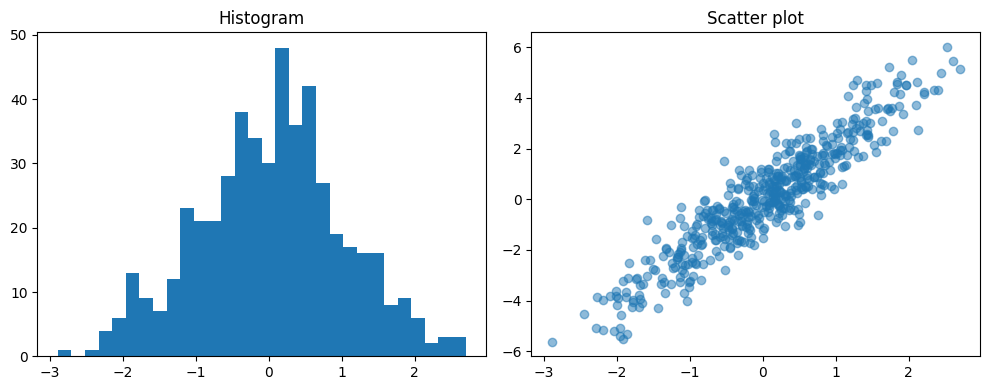

In [9]:
x = rng.normal(size=500)
y = 2 * x + rng.normal(scale=0.8, size=500)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(x, bins=30)
plt.title("Histogram")

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.5)
plt.title("Scatter plot")
plt.tight_layout()
plt.show()

<a id=8-estimators-bias-and-standard-error></a>
# 8. Estimators, Bias, and Standard Error

### Estimator vs estimate

An **estimator** is a rule or formula.  
An **estimate** is the numerical result obtained from a sample.

### Bias

An estimator is **biased** if its expected value systematically differs from the true parameter.

### Standard error

The **standard error** measures how much an estimator varies across repeated samples.

For the sample mean, it is often written as

$$
SE(\bar{x}) = \frac{s}{\sqrt{n}}
$$

### Why this matters in ML

These ideas help us understand:

- uncertainty of estimates;
- stability of reported metrics;
- why small samples are risky;
- why repeated sampling matters.

### Common mistakes

- Confusing standard deviation with standard error.
- Thinking one sample estimate is exact truth.
- Ignoring uncertainty around averages and metrics.

### ML takeaway

Statistical estimates are not fixed truths; they have uncertainty.

### Quick check

1. What is the difference between an estimator and an estimate?  
2. What does standard error measure?  
3. Why does larger sample size usually reduce standard error?

[Back to Topics](#topics-covered)

In [10]:
for n in [20, 50, 200, 1000]:
    sample = rng.normal(loc=10, scale=4, size=n)
    se = sample.std(ddof=1) / np.sqrt(n)
    print(f"n={n:4d}, mean={sample.mean():.3f}, standard error={se:.3f}")

n=  20, mean=10.761, standard error=0.830
n=  50, mean=10.481, standard error=0.558
n= 200, mean=10.212, standard error=0.279
n=1000, mean=10.129, standard error=0.130


<a id=9-confidence-intervals></a>
# 9. Confidence Intervals

### What is a confidence interval?

A **confidence interval** gives a range of plausible values for an unknown population parameter.

A simple approximate confidence interval for the mean is

$$
\bar{x} \pm z_{\alpha/2} \cdot \frac{s}{\sqrt{n}}
$$

### Why this matters in ML

Confidence intervals are useful for:

- quantifying uncertainty;
- reporting model metrics more responsibly;
- comparing groups or models;
- avoiding overconfidence in point estimates.

### Common mistakes

- Interpreting a 95% CI as “95% probability the true value is in this one interval”.
- Reporting only point estimates when uncertainty matters.

### ML takeaway

A confidence interval adds uncertainty awareness to statistical summaries.

### Quick check

1. Why is a confidence interval more informative than a single estimate?  
2. What happens to CI width as sample size grows?  
3. Why are confidence intervals useful in model evaluation?

[Back to Topics](#topics-covered)

In [11]:
sample = rng.normal(loc=5, scale=2, size=200)
mean_ = sample.mean()
std_ = sample.std(ddof=1)
se_ = std_ / np.sqrt(len(sample))
z_975 = 1.96
ci_low = mean_ - z_975 * se_
ci_high = mean_ + z_975 * se_
print("Approximate 95% CI:", (ci_low, ci_high))

Approximate 95% CI: (np.float64(4.987420668332944), np.float64(5.602160921452149))


<a id=10-bootstrapping></a>
# 10. Bootstrapping

### What is bootstrapping?

**Bootstrapping** is a resampling method.

We repeatedly sample **with replacement** from the observed data and recompute a statistic.

This produces an empirical distribution of the statistic.

### Why this matters in ML

Bootstrapping is useful for:

- confidence intervals;
- metric variability;
- uncertainty estimation;
- robust analysis when theory is difficult.

### Common mistakes

- Forgetting that bootstrap sampling is with replacement.
- Believing bootstrap creates new information rather than resampling observed information.

### ML takeaway

Bootstrapping is a practical way to estimate uncertainty directly from data.

### Quick check

1. Why does bootstrapping resample with replacement?  
2. What can bootstrap distributions be used for?  
3. Why is bootstrapping useful in ML evaluation?

[Back to Topics](#topics-covered)

In [12]:
data = rng.normal(loc=10, scale=2, size=200)
bootstrap_means = []
for _ in range(2000):
    sample = rng.choice(data, size=len(data), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)
print("Bootstrap 95% CI:", np.percentile(bootstrap_means, [2.5, 97.5]))

Bootstrap 95% CI: [ 9.7688 10.3746]


<a id=11-covariance-and-correlation></a>
# 11. Covariance and Correlation

### Covariance

Covariance measures how two variables vary together:

$$
\text{Cov}(X,Y)=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

### Correlation

The Pearson correlation coefficient is

$$
r = \frac{\text{Cov}(X,Y)}{s_X s_Y}
$$

It measures **linear dependence**.

### Why this matters in ML

Correlation helps with:

- feature selection;
- redundancy analysis;
- exploratory data analysis;
- multicollinearity warning.

### Correlation is not causation

A strong correlation does not prove a causal relationship.

### Common mistakes

- Confusing correlation with causation.
- Assuming zero correlation means no relationship at all.
- Ignoring nonlinear dependence.

### ML takeaway

Correlation is useful, but it is only one lens on dependence.

### Quick check

1. What does covariance measure?  
2. What extra normalization does correlation add?  
3. Why does correlation not imply causation?

[Back to Topics](#topics-covered)

In [13]:
x = rng.normal(size=500)
y = 3 * x + rng.normal(scale=0.8, size=500)
print("Covariance:", np.cov(x, y, ddof=1)[0, 1])
print("Correlation:", np.corrcoef(x, y)[0, 1])

Covariance: 2.9478340958065483
Correlation: 0.9655607149116676


<a id=12-multicollinearity-and-vif></a>
# 12. Multicollinearity and VIF

### What is multicollinearity?

**Multicollinearity** means strong linear dependence between two or more predictor variables.

### Why is it a problem?

It can cause:

- unstable coefficient estimates;
- inflated variance of estimates;
- misleading interpretation;
- low statistical significance of coefficients.

### Variance Inflation Factor (VIF)

A common diagnostic is

$$
VIF = \frac{1}{1-R^2}
$$

where $R^2$ is obtained by regressing one predictor on the others.

### Why this matters in ML

Multicollinearity is especially important in:

- linear regression;
- logistic regression;
- interpretable coefficient-based models.

### Common mistakes

- Thinking multicollinearity always ruins prediction quality in every model.
- Ignoring it when interpretation of coefficients matters.

### ML takeaway

Multicollinearity mainly hurts interpretability and coefficient stability.

### Quick check

1. What is multicollinearity?  
2. Why can it make coefficients unstable?  
3. Why is VIF useful?

[Back to Topics](#topics-covered)

In [14]:
x1 = rng.normal(size=500)
x2 = 2 * x1 + rng.normal(scale=0.05, size=500)
x3 = rng.normal(size=500)

X_reg = np.column_stack([np.ones(len(x1)), x1, x3])
beta = np.linalg.lstsq(X_reg, x2, rcond=None)[0]
x2_hat = X_reg @ beta
ss_res = np.sum((x2 - x2_hat) ** 2)
ss_tot = np.sum((x2 - x2.mean()) ** 2)
R2 = 1 - ss_res / ss_tot
vif_x2 = 1 / (1 - R2)

print("Approximate VIF for x2:", vif_x2)

Approximate VIF for x2: 1618.8941211110116


<a id=13-hypotheses-significance-and-p-value></a>
# 13. Hypotheses, Significance, and p-value

### Hypotheses

A **null hypothesis** $H_0$ usually says there is no effect or no difference.

An **alternative hypothesis** $H_1$ says there is an effect or difference.

### Significance level

The significance level is often denoted by $\alpha$.

### p-value

A **p-value** measures how surprising the observed data would be if the null hypothesis were true.

### Why this matters in ML

Hypothesis testing matters for:

- model comparison;
- A/B testing;
- feature relevance studies;
- security and anomaly analysis.

### Common mistakes

- Thinking p-value is the probability that $H_0$ is true.
- Treating statistical significance as practical importance.
- Using 0.05 mechanically without context.

### ML takeaway

p-values are about evidence against a null hypothesis, not about model truth in absolute terms.

### Quick check

1. What is the role of the null hypothesis?  
2. What does a small p-value suggest?  
3. Why is statistical significance not the same as practical significance?

[Back to Topics](#topics-covered)

In [15]:
group1 = rng.normal(loc=10, scale=2, size=100)
group2 = rng.normal(loc=10.7, scale=2, size=100)

if SCIPY_AVAILABLE:
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    print("t-statistic:", t_stat)
    print("p-value:", p_val)
else:
    print("SciPy is not available.")

t-statistic: -3.246032703245695
p-value: 0.0013752858999093915


<a id=14-type-i-and-type-ii-errors></a>
# 14. Type I and Type II Errors

### Type I error

A **Type I error** means rejecting the null hypothesis when it is actually true.

This is a **false positive**.

### Type II error

A **Type II error** means failing to reject the null hypothesis when it is actually false.

This is a **false negative**.

### Why this matters in ML

These errors are connected to:

- false alarms vs missed detections;
- cybersecurity filtering;
- anomaly detection;
- medical and high-stakes ML decisions.

### A practical intuition

Suppose a company deploys a phishing detector.

- Type I error: a safe email is wrongly flagged as malicious.
- Type II error: a malicious email is wrongly treated as safe.

Different systems may prefer different trade-offs.

### Common mistakes

- Focusing only on one error type.
- Ignoring business or safety cost when choosing thresholds.

### ML takeaway

Different statistical errors have different real-world costs.

### Quick check

1. What is a Type I error?  
2. What is a Type II error?  
3. Why are these ideas relevant to anomaly detection or filtering systems?

[Back to Topics](#topics-covered)

In [16]:
print("Type I error  = false positive")
print("Type II error = false negative")

print("\nPhishing detector example:")
print("Type I: safe email flagged as malicious")
print("Type II: malicious email missed")

Type I error  = false positive
Type II error = false negative

Phishing detector example:
Type I: safe email flagged as malicious
Type II: malicious email missed


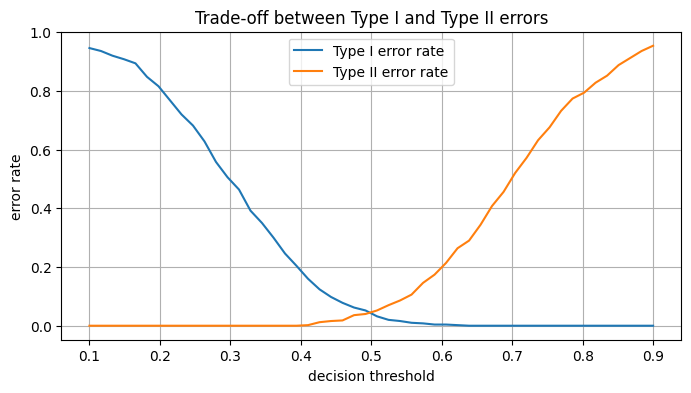

In [17]:
scores_safe = rng.normal(loc=0.3, scale=0.12, size=500)
scores_attack = rng.normal(loc=0.7, scale=0.12, size=500)

thresholds = np.linspace(0.1, 0.9, 50)
type1_rates = []
type2_rates = []

for t in thresholds:
    type1 = np.mean(scores_safe >= t)
    type2 = np.mean(scores_attack < t)
    type1_rates.append(type1)
    type2_rates.append(type2)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, type1_rates, label="Type I error rate")
plt.plot(thresholds, type2_rates, label="Type II error rate")
plt.xlabel("decision threshold")
plt.ylabel("error rate")
plt.title("Trade-off between Type I and Type II errors")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
t = 0.5
fp = np.sum(scores_safe >= t)
tn = np.sum(scores_safe < t)
fn = np.sum(scores_attack < t)
tp = np.sum(scores_attack >= t)

print("Chosen threshold:", t)
print("True negatives:", tn)
print("False positives (Type I):", fp)
print("False negatives (Type II):", fn)
print("True positives:", tp)

Chosen threshold: 0.5
True negatives: 478
False positives (Type I): 22
False negatives (Type II): 22
True positives: 478


<a id=15-common-statistical-tests></a>
# 15. Common Statistical Tests

### What is a test statistic?

A **test statistic** is a number computed from the sample that summarizes evidence against the null hypothesis.

Examples:

- in a **t-test**, the statistic measures how large the observed mean difference is relative to sample variability;
- in an **F-test**, the statistic compares two sources of variance.

### t-test intuition

A **t-statistic** becomes large in magnitude when:

- the difference between groups is large;
- the variability is relatively small;
- the sample size supports stable estimation.

So the t-test asks:

> Is the observed difference large compared with the noise?

### F-test intuition

An **F-statistic** is a ratio of variances.

In ANOVA, it compares:

- variance between groups;
- variance within groups.

If the between-group variance is much larger, the F-statistic becomes large.

### Useful tests to know

#### One-sample t-test
Tests whether a sample mean differs from a reference value.

#### Independent two-sample t-test
Tests whether two groups have different means.

#### Paired t-test
Tests whether paired observations differ in mean.

#### Chi-square test
Often used for categorical data and contingency tables.

#### Nonparametric alternatives
Examples: Mann–Whitney U, Wilcoxon.

### Why this matters in ML

These tests are useful for:

- before/after comparisons;
- model comparison;
- categorical association checks;
- robust alternatives when assumptions are weak.

### Common mistakes

- Using a test without checking assumptions.
- Choosing parametric tests blindly for very non-normal or ordinal data.
- Treating the test statistic as meaningful without understanding what it compares.

### ML takeaway

Statistical tests help formalize whether observed differences are likely meaningful.

### Quick check

1. What does a t-statistic compare conceptually?  
2. What does an F-statistic compare conceptually?  
3. When would you prefer a paired t-test over an independent t-test?

[Back to Topics](#topics-covered)

In [19]:
tests_df = pd.DataFrame({
    "Test": ["One-sample t-test", "Independent t-test", "Paired t-test", "Chi-square", "Mann-Whitney U"],
    "Use case": [
        "sample mean vs reference value",
        "two independent groups",
        "before/after or paired observations",
        "association in categorical data",
        "nonparametric comparison of two groups"
    ]
})
display(tests_df)

,Test,Use case
0,One-sample t-test,sample mean vs reference value
1,Independent t-test,two independent groups
2,Paired t-test,before/after or paired observations
3,Chi-square,association in categorical data
4,Mann-Whitney U,nonparametric comparison of two groups


In [20]:
group1 = rng.normal(loc=20, scale=3, size=80)
group2 = rng.normal(loc=21.2, scale=3, size=80)

mean_diff = group2.mean() - group1.mean()
print("Group 1 mean:", group1.mean())
print("Group 2 mean:", group2.mean())
print("Observed mean difference:", mean_diff)

if SCIPY_AVAILABLE:
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    print("t-statistic:", t_stat)
    print("p-value:", p_val)

Group 1 mean: 20.140679866510045
Group 2 mean: 21.15840610180789
Observed mean difference: 1.0177262352978467
t-statistic: -2.0539309944989466
p-value: 0.04164762217560588


In [21]:
before = rng.normal(loc=70, scale=8, size=60)
after = before + rng.normal(loc=2.0, scale=4, size=60)

diff = after - before
print("Average paired difference:", diff.mean())

if SCIPY_AVAILABLE:
    t_stat, p_val = stats.ttest_rel(after, before)
    print("Paired t-statistic:", t_stat)
    print("Paired p-value:", p_val)

Average paired difference: 1.1989008759918816
Paired t-statistic: 2.045604690159688
Paired p-value: 0.0452619404786683


<a id=16-anova></a>
# 16. ANOVA

### What is ANOVA?

**ANOVA** stands for Analysis of Variance.

It is used when we want to compare more than two group means.

### Core intuition

ANOVA compares:

- variance **between groups**;
- variance **within groups**.

If between-group variability is large relative to within-group variability, that supports the idea that not all group means are equal.

### Why this matters in ML

ANOVA is useful for:

- comparing several model variants;
- studying grouped effects;
- feature analysis across categories.

### F-statistic in ANOVA

The ANOVA F-statistic is essentially:

$$
F = \frac{\text{between-group variance}}{\text{within-group variance}}
$$

So:

- large $F$ means groups differ more than would be expected from ordinary within-group noise;
- small $F$ means group differences are not much larger than internal variation.

### A practical interpretation

Suppose we compare 3 different ML preprocessing pipelines and observe validation scores.

ANOVA asks:

> Are the differences among the average scores of these pipelines larger than what we would expect from random variability?

### Common mistakes

- Performing many pairwise t-tests instead of using ANOVA first.
- Forgetting that ANOVA tells us whether a difference exists, but not automatically where.
- Seeing a large F-statistic and thinking it directly tells which group is best.

### ML takeaway

ANOVA is the natural extension of two-group mean comparison to multiple groups.

### Quick check

1. Why is ANOVA useful when there are more than two groups?  
2. What does the F-statistic compare conceptually?  
3. Why is it better than many separate t-tests as a first step?

[Back to Topics](#topics-covered)

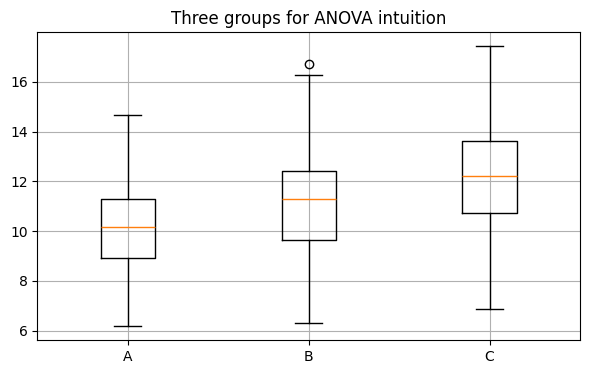

In [22]:
group_a = rng.normal(loc=10, scale=2, size=100)
group_b = rng.normal(loc=11, scale=2, size=100)
group_c = rng.normal(loc=12, scale=2, size=100)

plt.figure(figsize=(7, 4))
plt.boxplot([group_a, group_b, group_c], labels=["A", "B", "C"])
plt.title("Three groups for ANOVA intuition")
plt.grid(True)
plt.show()

In [23]:
groups = [group_a, group_b, group_c]
group_means = [g.mean() for g in groups]
overall_mean = np.concatenate(groups).mean()

print("Group means:", group_means)
print("Overall mean:", overall_mean)

between = sum(len(g) * (g.mean() - overall_mean) ** 2 for g in groups)
within = sum(np.sum((g - g.mean()) ** 2) for g in groups)

print("Between-group sum of squares:", between)
print("Within-group sum of squares:", within)
print("Between/Within ratio (intuition for F):", between / within)

Group means: [np.float64(10.152261169810938), np.float64(11.152656325203811), np.float64(12.134038936059847)]
Overall mean: 11.1463188103582
Between-group sum of squares: 196.3781803540885
Within-group sum of squares: 1348.9303475552647
Between/Within ratio (intuition for F): 0.14558066745995796


In [24]:
if SCIPY_AVAILABLE:
    f_stat, p_val = stats.f_oneway(group_a, group_b, group_c)
    print("ANOVA F-statistic:", f_stat)
    print("ANOVA p-value:", p_val)
else:
    print("SciPy is not available.")

ANOVA F-statistic: 21.618729117803802
ANOVA p-value: 1.716671184574558e-09


<a id=17-regression-from-a-statistical-viewpoint></a>
# 17. Regression from a Statistical Viewpoint

### Correlation vs regression

Correlation measures association.  
Regression models dependence for prediction or explanation.

### Simple linear regression

A basic linear model is

$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

where $\varepsilon$ is the residual or noise term.

### Logistic regression

Logistic regression can be viewed statistically as a model for class probability.

It models

$$
P(y=1 \mid x)
$$

through a sigmoid transformation.

### Why this matters in ML

Regression connects classical statistics and machine learning.

It helps with:

- baselines;
- interpretation;
- probabilistic classification;
- residual analysis.

### Common mistakes

- Confusing strong fit with causal interpretation.
- Ignoring residual diagnostics.
- Forgetting that logistic regression is probabilistic.

### ML takeaway

Regression is one of the most important bridges between statistics and machine learning.

### Quick check

1. What is the difference between correlation and regression?  
2. What do residuals represent?  
3. Why can logistic regression be viewed as statistical classification?

[Back to Topics](#topics-covered)

In [25]:
x = rng.normal(size=300)
y = 2.5 * x + rng.normal(scale=1.0, size=300)

X_design = np.column_stack([np.ones(len(x)), x])
beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
y_hat = X_design @ beta
residuals = y - y_hat

print("Estimated intercept:", beta[0])
print("Estimated slope:", beta[1])

Estimated intercept: -0.0240511375242954
Estimated slope: 2.392265272885762


<a id=18-practical-eda-workflow-for-ml></a>
# 18. Practical EDA Workflow for ML

### A practical sequence

A good ML-oriented statistical workflow often looks like this:

1. inspect variable types;
2. check missing values;
3. compute summary statistics;
4. plot distributions;
5. inspect outliers;
6. inspect correlations;
7. think about transformations and scaling;
8. check target balance;
9. look for leakage or sampling issues;
10. only then move to modeling.

### Why this matters in ML

Good statistical EDA reduces mistakes later in modeling.

### Common mistakes

- Jumping to modeling too early.
- Ignoring missing values and outliers.
- Forgetting leakage and sampling shift.

### ML takeaway

Strong ML practice starts with strong statistical inspection of data.

### Quick check

1. Why should EDA come before modeling?  
2. What kinds of issues can EDA reveal early?  
3. Why is leakage partly a statistical problem, not only a coding problem?

[Back to Topics](#topics-covered)

In [26]:
df = pd.DataFrame({
    "feature_1": rng.normal(size=300),
    "feature_2": rng.exponential(size=300),
    "feature_3": rng.normal(loc=5, scale=2, size=300),
    "target": rng.integers(0, 2, size=300)
})

display(df.head())
display(df.describe())
display(df.corr())

,feature_1,feature_2,feature_3,target
0,1.166540,0.614366,5.651842,1
1,-1.934261,1.765918,6.582955,0
2,-0.233255,1.203121,0.719065,0
3,-1.429255,0.041259,7.877545,0
4,0.308096,2.204618,4.111522,0


,feature_1,feature_2,feature_3,target
count,300.000000,300.000000,300.000000,300.000000
mean,-0.033811,0.990263,4.928322,0.506667
std,0.947852,0.984763,1.986776,0.500791
min,-2.665081,0.000191,-1.021258,0.000000
25%,-0.698776,0.265886,3.713477,0.000000
50%,-0.043526,0.669750,4.896906,1.000000
75%,0.599485,1.475173,6.252204,1.000000
max,2.758151,6.991576,10.245793,1.000000


,feature_1,feature_2,feature_3,target
feature_1,1.000000,0.054852,0.024643,-0.004203
feature_2,0.054852,1.000000,0.028953,-0.056630
feature_3,0.024643,0.028953,1.000000,0.032405
target,-0.004203,-0.056630,0.032405,1.000000


#### [Math for ML. Part 1. Basics of Linear algebra & analytic geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part-1-lin-algebra-an-geometry)

#### [Math for ML - Part 2. Basics of calculus (Mathematical Analysis)](https://www.kaggle.com/code/kupershtein/math-for-ml-part-2-basics-of-calculus-matan)

#### [Math for ML - Part 3. Basics of probability theory](https://www.kaggle.com/code/kupershtein/math-for-ml-part-3-basics-of-probability-theory)
### **I hope it useful for you! Thanks for upvote!¶**